In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import seaborn as sns

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 55340 to 2836
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       10000 non-null  float64
 1   HighBP                10000 non-null  int64  
 2   HighChol              10000 non-null  float64
 3   CholCheck             10000 non-null  int64  
 4   BMI                   10000 non-null  float64
 5   Smoker                10000 non-null  float64
 6   Stroke                10000 non-null  float64
 7   HeartDiseaseorAttack  10000 non-null  float64
 8   PhysActivity          10000 non-null  int64  
 9   Fruits                10000 non-null  int64  
 10  Veggies               10000 non-null  int64  
 11  HvyAlcoholConsump     10000 non-null  int64  
 12  AnyHealthcare         10000 non-null  int64  
 13  NoDocbcCost           10000 non-null  float64
 14  GenHlth               10000 non-null  float64
 15  MentHlth             

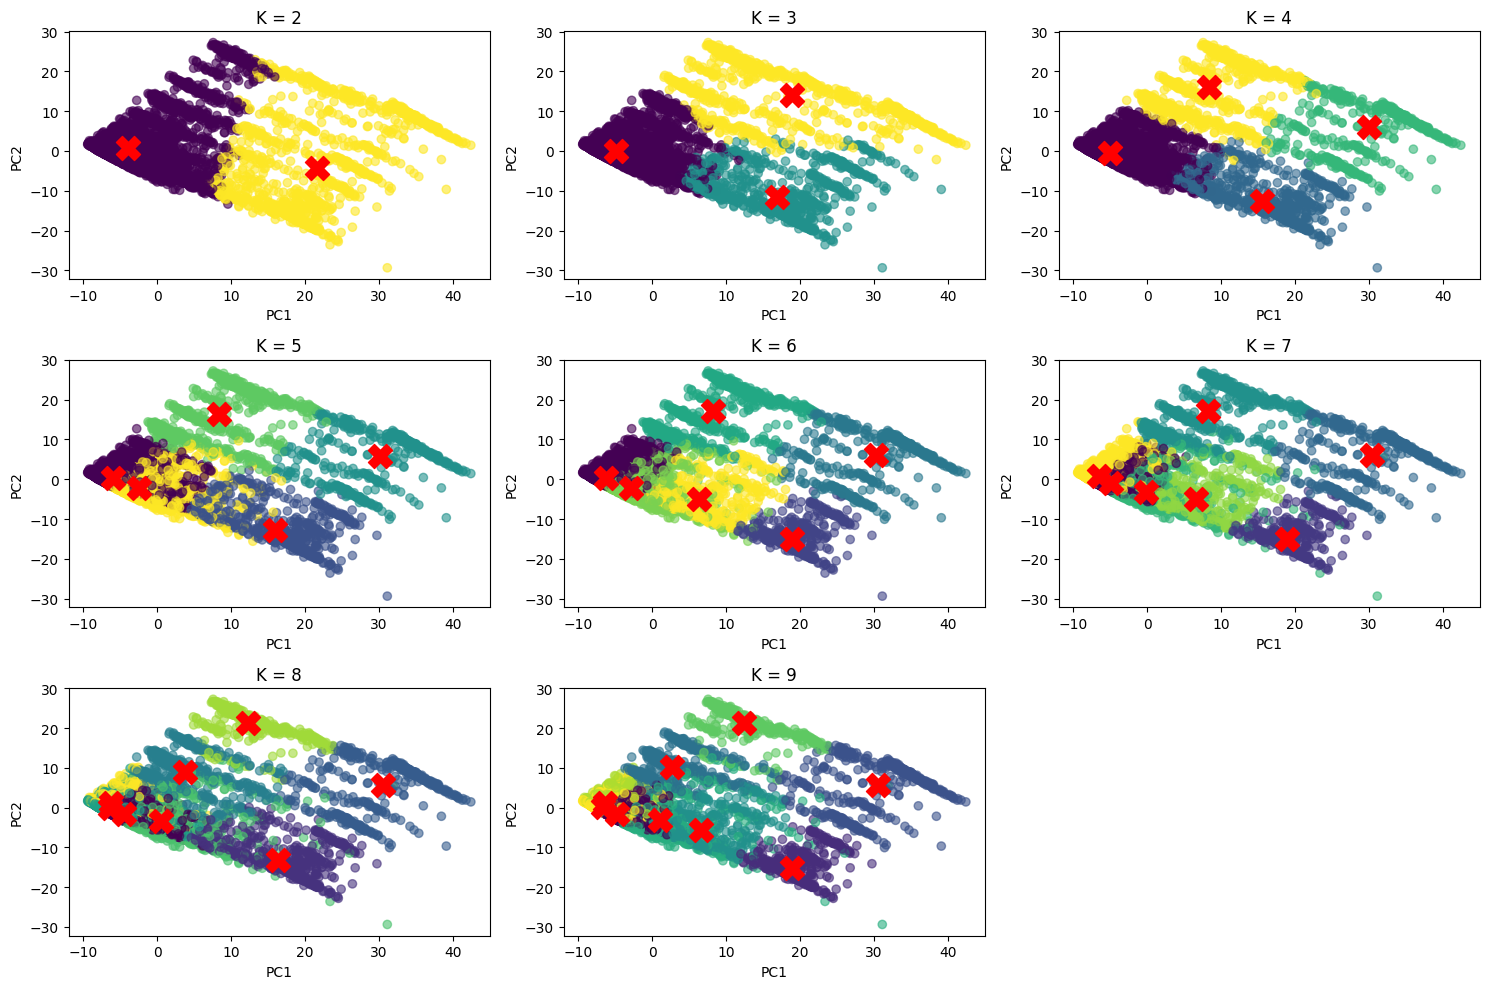

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Cargar los datos
url = 'https://raw.githubusercontent.com/Zephyrodes/Datasets/main/diabetes_binary_5050split_health_indicators_BRFSS2021.csv'
df = pd.read_csv(url)

# Selección de columnas
df_sample = df.sample(n=10000, random_state=42)
df_sample.head()
df_sample.info()
df_sample.describe()
# Reducir dimensiones para visualización
pca = PCA(n_components=4)
X_pca = pca.fit_transform(df_sample.values)


# Probar diferentes valores de K
plt.figure(figsize=(15, 10))
for i, k in enumerate(range(2, 10), 1):  # De K=2 a K=6
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_sample)

    labels = kmeans.labels_
    centroids_2d = pca.transform(kmeans.cluster_centers_)

    # Crear subgráfico
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
    plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=300, c='red', marker='X')
    plt.title(f'K = {k}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

plt.tight_layout()
plt.show()


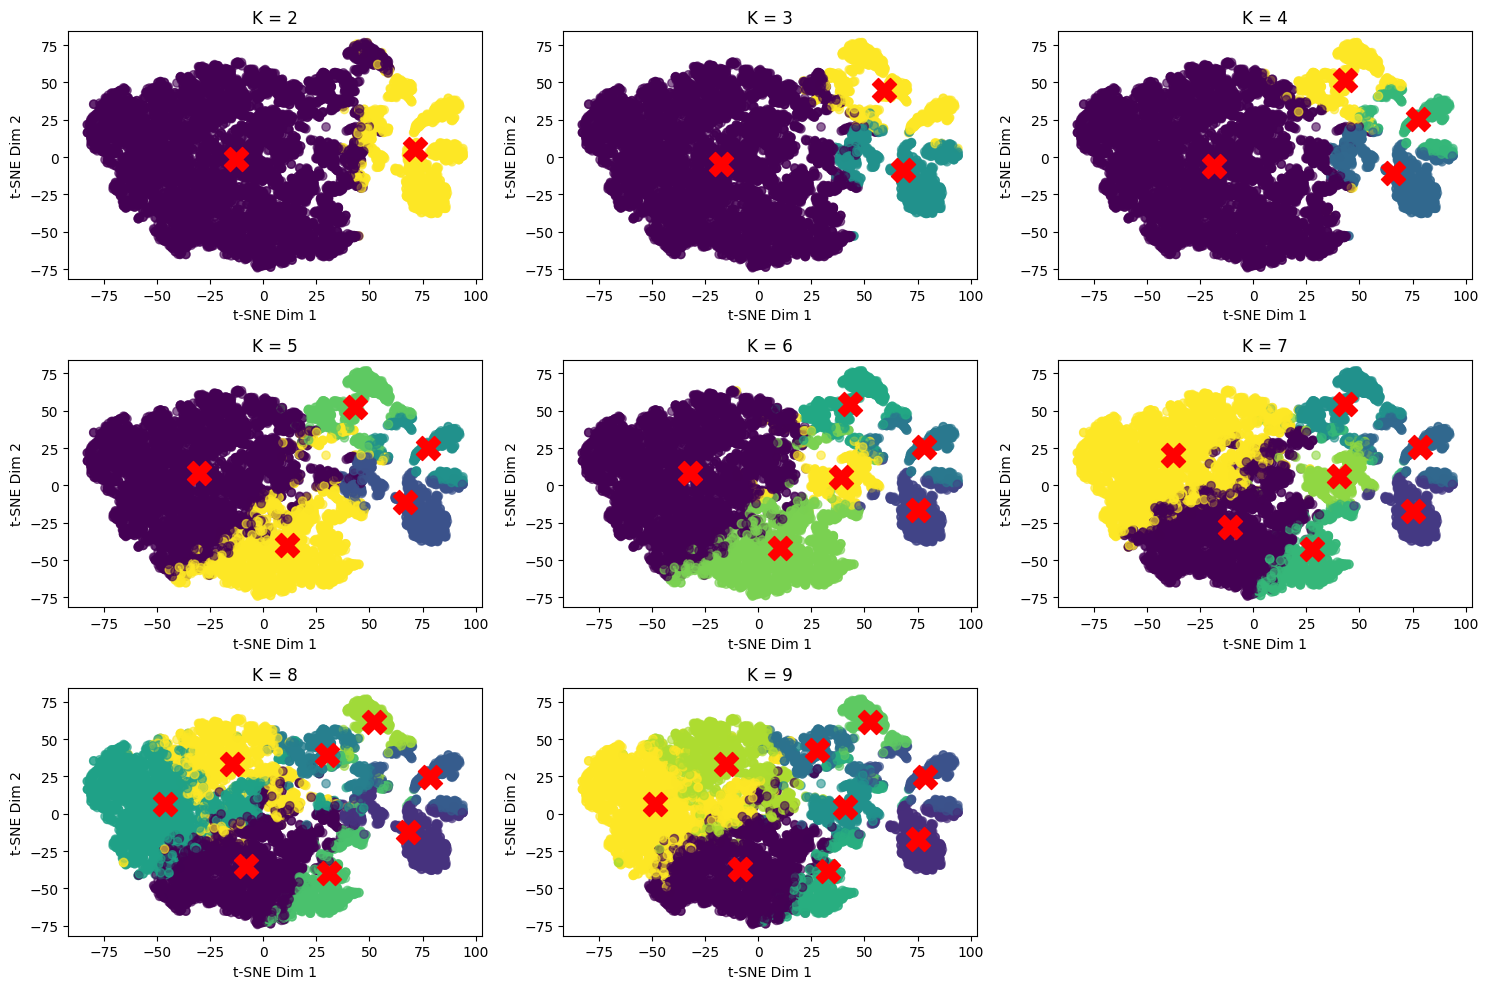

In [ ]:
# Aplicar t-SNE UNA SOLA VEZ a los datos
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(df_sample)

# Probar diferentes valores de K
plt.figure(figsize=(15, 10))
for i, k in enumerate(range(2, 10), 1):  # De K=2 a K=9
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_sample)

    labels = kmeans.labels_

    # Proyectar los centroides usando PCA (opcional) o no transformarlos
    # Alternativa simple: calcular el centroide medio de los puntos ya proyectados
    centroids_2d = []
    for j in range(k):
        cluster_points = X_tsne[labels == j]
        centroids_2d.append(cluster_points.mean(axis=0))
    centroids_2d = np.vstack(centroids_2d)

    # Crear subgráfico
    plt.subplot(3, 3, i)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', alpha=0.6)
    plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=300, c='red', marker='X')
    plt.title(f'K = {k}')
    plt.xlabel('t-SNE Dim 1')
    plt.ylabel('t-SNE Dim 2')

plt.tight_layout()
plt.show()


In [ ]:
# Calcular Silhouette Score para PCA y t-SNE
silhouette_pca = silhouette_score(X_pca, labels)
silhouette_tsne = silhouette_score(X_tsne, labels)

print(f"Silhouette Score en espacio PCA 2D: {silhouette_pca:.4f}")
print(f"Silhouette Score en espacio t-SNE 2D: {silhouette_tsne:.4f}")

Silhouette Score en espacio PCA 2D: 0.3036
Silhouette Score en espacio t-SNE 2D: 0.2762


El valor de k en el codo es: 2


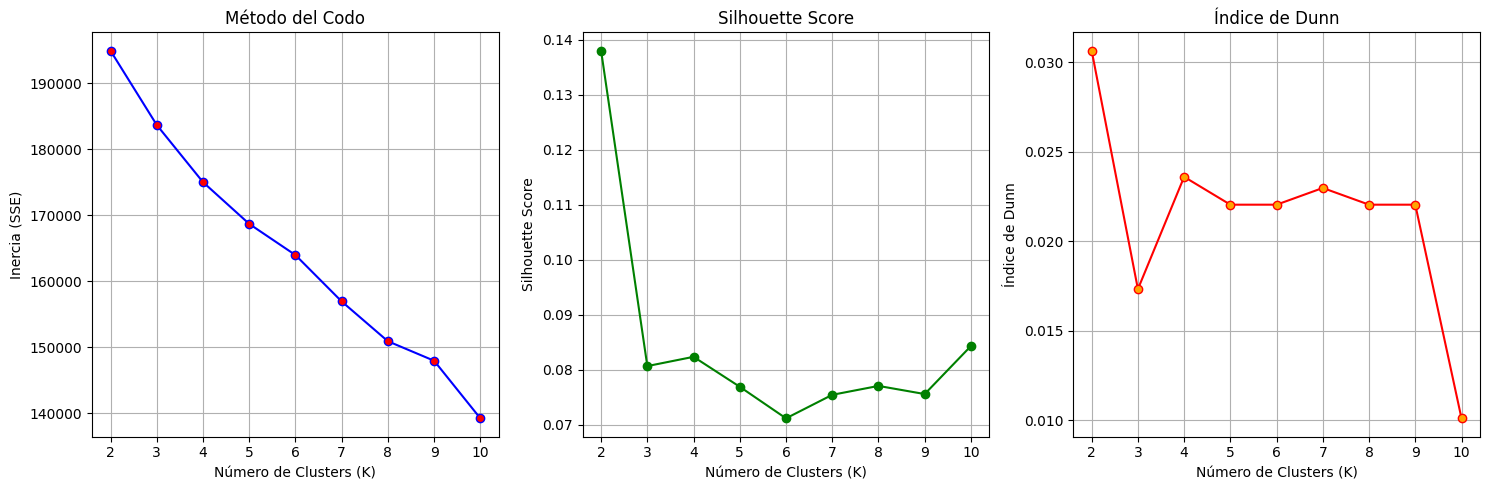

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import pairwise_distances

# Función alternativa para calcular el Índice de Dunn
def dunn_index(X, labels):
    # Distancia mínima entre clústeres
    clusters = np.unique(labels)
    min_intercluster_dist = np.inf
    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            cluster_i = X[labels == clusters[i]]
            cluster_j = X[labels == clusters[j]]
            dist = np.min(pairwise_distances(cluster_i, cluster_j))
            min_intercluster_dist = min(min_intercluster_dist, dist)

    # Distancia máxima dentro de un clúster
    max_intracluster_dist = -np.inf
    for cluster in clusters:
        cluster_data = X[labels == cluster]
        dist = np.max(pairwise_distances(cluster_data, cluster_data))
        max_intracluster_dist = max(max_intracluster_dist, dist)

    # Índice de Dunn
    return min_intercluster_dist / max_intracluster_dist

# 1. Escalado de los datos (asegúrate de que 'df_sample' es tu DataFrame de características)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

# 2. Definir el rango de k
k_range = range(2, 11)

# 3. Inicializar listas para almacenar las métricas
inertias = []
silhouette_scores = []
dunn_scores = []

# 4. Calcular las métricas para cada valor de k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)

    # Método del Codo (Inercia)
    inertias.append(kmeans.inertia_)

    # Verificar si se han creado más de 1 clúster
    if len(set(kmeans.labels_)) > 1:
        # Silhouette Score solo si hay más de 1 clúster
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

        # Índice de Dunn solo si hay más de 1 clúster
        dunn_scores.append(dunn_index(X_scaled, kmeans.labels_))
    else:
        # Si solo hay un clúster, agregar un valor 'None' para evitar el cálculo
        silhouette_scores.append(None)
        dunn_scores.append(None)

# Calcular las diferencias entre inercia para cada k
inertia_diff = np.diff(inertias)

# Buscar el "codo" como el índice donde la diferencia comienza a ser más pequeña
codo = np.argmax(inertia_diff < 0.1) + 2  # Añadir 2 porque 'np.diff' reduce el índice
print(f"El valor de k en el codo es: {codo}")

# 5. Graficar los resultados comparativos
plt.figure(figsize=(15, 5))

# Gráfico del Método del Codo (Inercia)
plt.subplot(1, 3, 1)
plt.plot(k_range, inertias, 'bo-', markerfacecolor='red')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (SSE)')
plt.xticks(k_range)
plt.grid(True)

# Gráfico del Silhouette Score
plt.subplot(1, 3, 2)
plt.plot(k_range, silhouette_scores, 'go-', markerfacecolor='green')
plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)

# Gráfico del Índice de Dunn
plt.subplot(1, 3, 3)
plt.plot(k_range, dunn_scores, 'ro-', markerfacecolor='orange')
plt.title('Índice de Dunn')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Índice de Dunn')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Definir columnas numéricas a usar (excluye la columna objetivo si la tienes)
features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Outcome' in features:
    features.remove('Outcome')  # cambia 'Outcome' por el nombre real de tu target si es diferente

# Aplicar KMeans con k óptimo
from sklearn.cluster import KMeans

k_optimo = 4
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
df['cluster'] = kmeans.fit_predict(df[features])

# Tabla resumen con medias por clúster
cluster_summary = df.groupby('cluster')[features].mean().round(2)

print("Tabla resumen de medias por clúster:")
display(cluster_summary)

# Análisis textual básico
print("\nAnálisis e interpretación:")
for cluster_id, row in cluster_summary.iterrows():
    glucosa = row.get('Glucose', None)
    bmi = row.get('BMI', None)
    edad = row.get('Age', None)
    dpfunc = row.get('DiabetesPedigreeFunction', None)

    perfil = []
    if glucosa is not None:
        if glucosa < 100:
            perfil.append("niveles bajos de glucosa (bajo riesgo)")
        elif glucosa > 125:
            perfil.append("niveles altos de glucosa (alto riesgo)")
        else:
            perfil.append("niveles moderados de glucosa (riesgo medio)")
    if bmi is not None:
        if bmi < 25:
            perfil.append("peso normal")
        elif bmi >= 30:
            perfil.append("sobrepeso u obesidad")
        else:
            perfil.append("peso ligeramente elevado")
    if edad is not None:
        if edad < 30:
            perfil.append("pacientes jóvenes")
        elif edad > 50:
            perfil.append("pacientes adultos mayores")
        else:
            perfil.append("pacientes adultos")

    print(f"\nCluster {cluster_id}:")
    print(f"  - Características: {', '.join(perfil)}.")
    print("  - Este grupo representa un segmento con necesidades específicas de seguimiento y prevención.")


Tabla resumen de medias por clúster:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.58,0.59,0.56,0.97,31.98,0.55,0.10,0.19,0.55,0.54,...,0.95,0.18,3.52,26.63,13.10,0.44,0.38,7.66,4.81,5.33
1,0.63,0.67,0.53,0.99,38.15,0.42,0.05,0.12,0.67,0.56,...,0.97,0.06,2.87,1.99,1.74,0.25,0.48,8.19,4.99,6.52
2,0.71,0.72,0.62,0.99,32.03,0.55,0.13,0.28,0.47,0.58,...,0.97,0.10,3.94,3.71,26.34,0.62,0.48,9.46,4.77,5.41
3,0.39,0.46,0.45,0.97,26.48,0.41,0.04,0.11,0.81,0.64,...,0.97,0.04,2.38,1.39,0.98,0.11,0.52,8.58,5.15,7.02



Análisis e interpretación:

Cluster 0:
  - Características: sobrepeso u obesidad, pacientes jóvenes.
  - Este grupo representa un segmento con necesidades específicas de seguimiento y prevención.

Cluster 1:
  - Características: sobrepeso u obesidad, pacientes jóvenes.
  - Este grupo representa un segmento con necesidades específicas de seguimiento y prevención.

Cluster 2:
  - Características: sobrepeso u obesidad, pacientes jóvenes.
  - Este grupo representa un segmento con necesidades específicas de seguimiento y prevención.

Cluster 3:
  - Características: peso ligeramente elevado, pacientes jóvenes.
  - Este grupo representa un segmento con necesidades específicas de seguimiento y prevención.


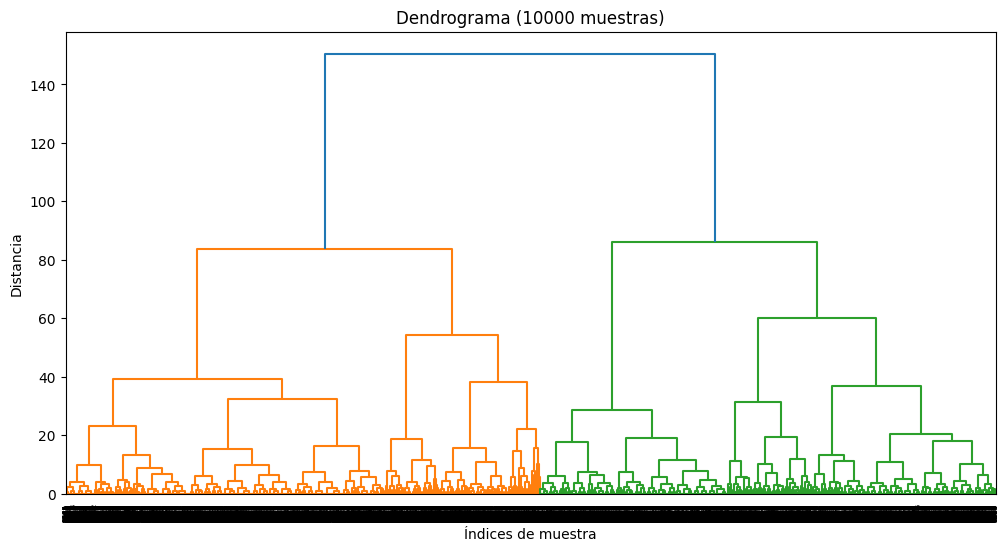

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Selección de columnas
df_sample = df[['BMI', 'Age', 'Diabetes_binary']].sample(n=10000, random_state=42)

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

# Clustering jerárquico
linked = linkage(X_scaled, method='ward')  # Puedes probar 'complete', 'average'

# Dendrograma
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title('Dendrograma (10000 muestras)')
plt.xlabel('Índices de muestra')
plt.ylabel('Distancia')
plt.show()


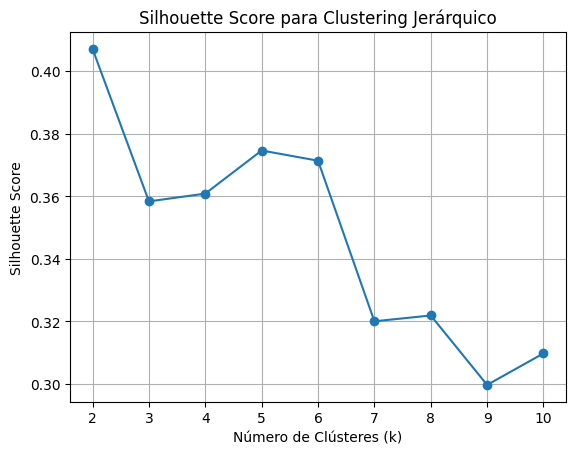

🔎 k óptimo según Silhouette Score: 2


In [ ]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Asumiendo que ya tienes: X_scaled y linked
silhouette_scores = []

# Evaluar para k entre 2 y 10
for k in range(2, 11):
    labels = fcluster(linked, k, criterion='maxclust')  # Asignar etiquetas
    score = silhouette_score(X_scaled, labels)          # Calcular Silhouette Score
    silhouette_scores.append(score)

# Gráfica del Silhouette Score
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para Clustering Jerárquico')
plt.grid(True)
plt.show()

# Mostrar el valor óptimo de k
k_optimo = np.argmax(silhouette_scores) + 2
print(f"🔎 k óptimo según Silhouette Score: {k_optimo}")


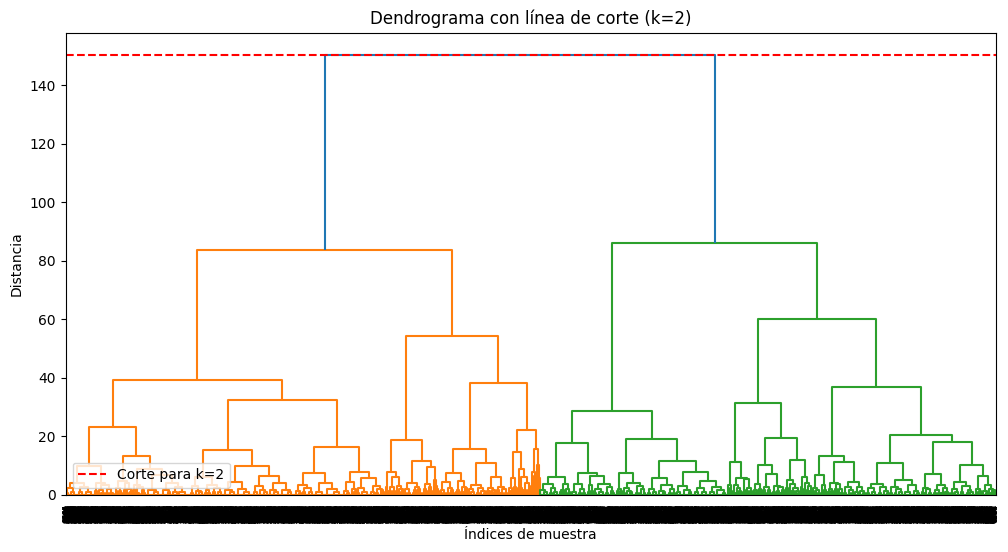

In [ ]:
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode=None)
# Línea de corte en la altura correspondiente a k óptimo
plt.axhline(y=linked[-(k_optimo-1), 2], color='red', linestyle='--', label=f'Corte para k={k_optimo}')
plt.title(f'Dendrograma con línea de corte (k={k_optimo})')
plt.xlabel('Índices de muestra')
plt.ylabel('Distancia')
plt.legend()
plt.show()

In [ ]:
# Etiquetas de clúster para el valor óptimo de k
labels_finales = fcluster(linked, k_optimo, criterion='maxclust')

# Imprimir los primeros 20 como ejemplo
print("🔹 Primeros 20 labels de clúster asignados:")
print(labels_finales[:20])

🔹 Primeros 20 labels de clúster asignados:
[1 2 1 2 1 2 1 1 2 1 2 2 1 1 1 2 2 2 1 2]


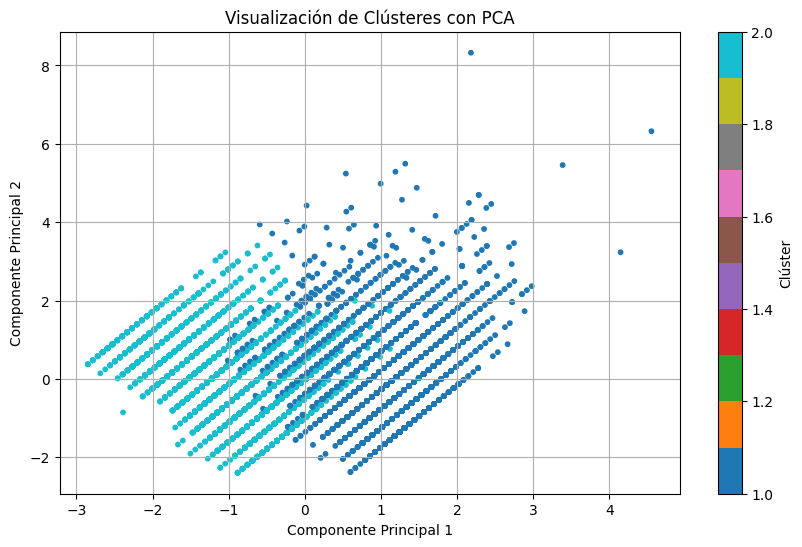

In [ ]:
# Aplicar PCA a los datos escalados
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Graficar los clústeres en el espacio PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_finales, cmap='tab10', s=10)
plt.title('Visualización de Clústeres con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Clúster')
plt.grid(True)
plt.show()

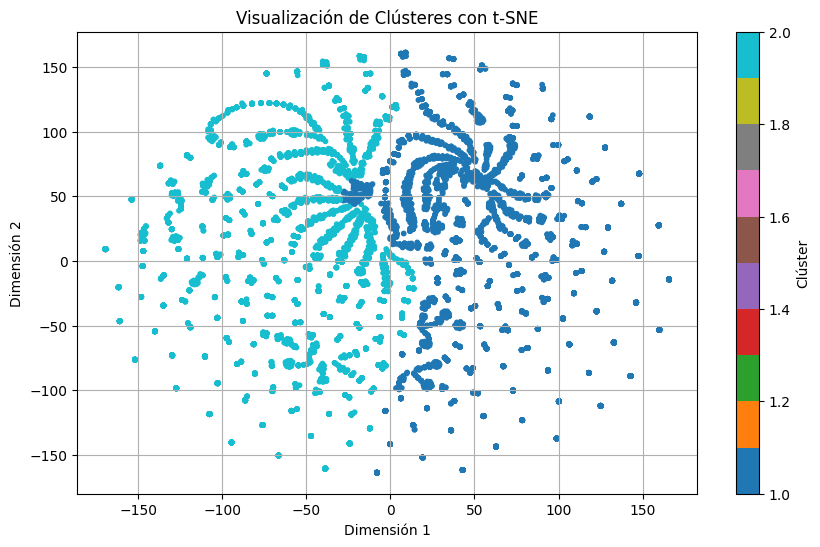

In [ ]:
from sklearn.manifold import TSNE

# Aplicar t-SNE (esto puede tardar un poco con 10,000 muestras)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Graficar los clústeres en el espacio t-SNE
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_finales, cmap='tab10', s=10)
plt.title('Visualización de Clústeres con t-SNE')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.colorbar(scatter, label='Clúster')
plt.grid(True)
plt.show()

In [ ]:
# Tabla cruzada: clúster vs diabetes_binary
df_sample['cluster'] = labels_finales
tabla_cruzada = pd.crosstab(df_sample['cluster'], df_sample['Diabetes_binary'])

print("🔍 Distribución de diabetes_binary dentro de cada clúster:")
print(tabla_cruzada)


🔍 Distribución de diabetes_binary dentro de cada clúster:
Diabetes_binary   0.0   1.0
cluster                    
1                  64  5036
2                4900     0


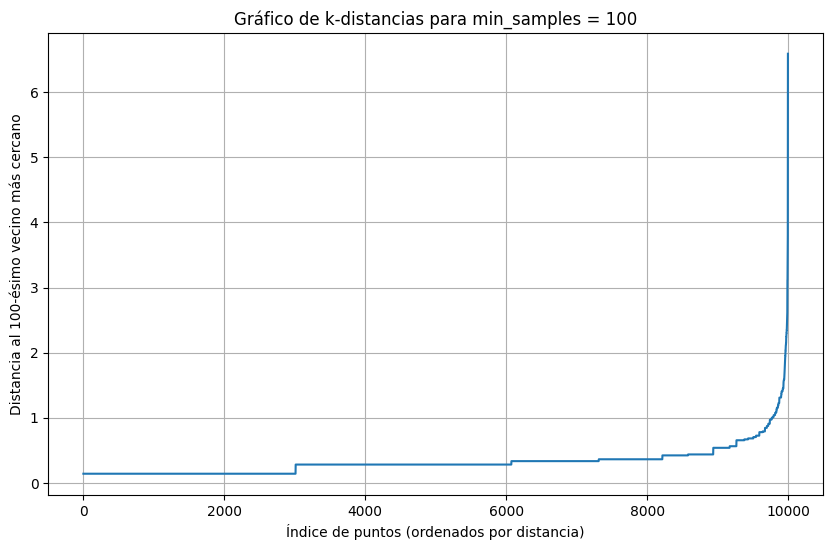

Observa el gráfico para identificar un 'codo' que sugiera un valor de eps.
Valores de k_distances para observar el 'codo':
[0.14079098 0.14079098 0.14079098 0.14079098 0.14079098 0.14079098
 0.14079098 0.14079098 0.14079098 0.14079098 0.14079098 0.14079098
 0.14079098 0.14079098 0.14079098 0.14079098 0.14079098 0.14079098
 0.14079098 0.14079098 0.14079098 0.14079098 0.14079098 0.14079098
 0.14079098 0.14079098 0.14079098 0.14079098 0.14079098 0.14079098
 0.14079098 0.28158196 0.28158196 0.28158196 0.28158196 0.28158196
 0.28158196 0.28158196 0.28158196 0.28158196 0.28158196 0.28158196
 0.28158196 0.28158196 0.28158196 0.28158196 0.28158196 0.28158196
 0.28158196 0.28158196 0.28158196 0.28158196 0.28158196 0.28158196
 0.28158196 0.28158196 0.28158196 0.28158196 0.28158196 0.28158196
 0.28158196 0.33418823 0.33418823 0.33418823 0.33418823 0.33418823
 0.33418823 0.33418823 0.33418823 0.33418823 0.33418823 0.33418823
 0.33418823 0.33418823 0.36263463 0.36263463 0.36263463 0.36263463
 0.362

In [ ]:

min_samples_val = 100
neigh = NearestNeighbors(n_neighbors=min_samples_val + 1)
neigh.fit(X_scaled)
distances, indices = neigh.kneighbors(X_scaled)

k_distances = np.sort(distances[:, min_samples_val], axis=0)
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel("Índice de puntos (ordenados por distancia)")
plt.ylabel(f"Distancia al {min_samples_val}-ésimo vecino más cercano")
plt.title(f"Gráfico de k-distancias para min_samples = {min_samples_val}")
plt.grid(True)
plt.show()

print(f"Observa el gráfico para identificar un 'codo' que sugiera un valor de eps.")
print(f"Valores de k_distances para observar el 'codo':")
print(k_distances[::len(k_distances)//100]) # Muestra algunos valores para ayudarte a identificar el codo

Aplicando DBSCAN con eps=0.65 y min_samples=100...

Resultados de DBSCAN:
Número total de puntos: 10000
Etiquetas de clústeres encontradas: [-1  0  1]
Número de clústeres identificados: 2
Número de puntos clasificados como ruido: 299 (2.99%)

Tamaño de cada clúster:
  Clúster 0: 4838 puntos
  Clúster 1: 4863 puntos

Reduciendo la dimensionalidad de 3 a 2 para visualización...
Aplicando t-SNE. Esto puede tomar un tiempo considerable para 10,000 puntos...


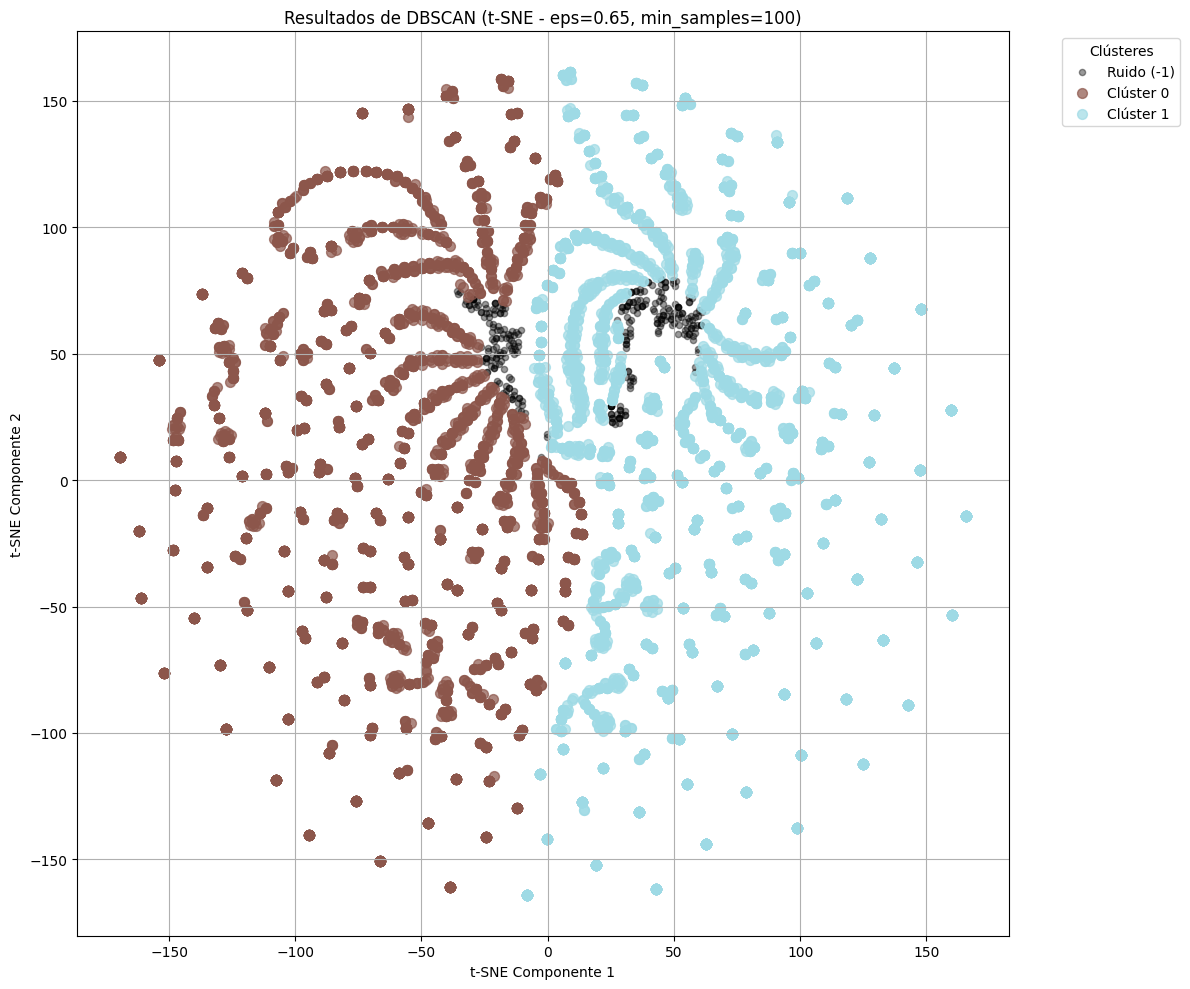


La visualización del gráfico de dispersión muestra los clústeres identificados.
Los puntos negros representan el ruido.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
tu_eps_estimado = 0.65
min_samples_para_dbscan = 100

print(f"Aplicando DBSCAN con eps={tu_eps_estimado} y min_samples={min_samples_para_dbscan}...")

# 3. Instanciar el modelo DBSCAN
dbscan = DBSCAN(eps=tu_eps_estimado, min_samples=min_samples_para_dbscan)

# 4. Ajustar el modelo y predecir los clústeres
clusters = dbscan.fit_predict(X_scaled)

# --- Análisis de los resultados ---
# Obtener las etiquetas únicas de los clústeres
unique_clusters = np.unique(clusters)

# Calcular el número de clústeres (excluyendo el ruido)
n_clusters = len(unique_clusters) - (1 if -1 in unique_clusters else 0)

# Calcular el número de puntos de ruido
n_noise_points = np.sum(clusters == -1)

print(f"\nResultados de DBSCAN:")
print(f"Número total de puntos: {len(X_scaled)}")
print(f"Etiquetas de clústeres encontradas: {unique_clusters}")
print(f"Número de clústeres identificados: {n_clusters}")
print(f"Número de puntos clasificados como ruido: {n_noise_points} ({n_noise_points / len(X_scaled) * 100:.2f}%)")

# Imprimir el tamaño de cada clúster
if n_clusters > 0:
    print("\nTamaño de cada clúster:")
    for cluster_id in sorted(unique_clusters):
        if cluster_id != -1:
            size = np.sum(clusters == cluster_id)
            print(f"  Clúster {cluster_id}: {size} puntos")

if X_scaled.shape[1] > 2:
    print(f"\nReduciendo la dimensionalidad de {X_scaled.shape[1]} a 2 para visualización...")

    print("Aplicando t-SNE. Esto puede tomar un tiempo considerable para 10,000 puntos...")
    tsne = TSNE(n_components=2, random_state=42, n_jobs=-1) # n_jobs=-1 para usar todos los núcleos
    X_viz = tsne.fit_transform(X_scaled)
    reduction_method = "t-SNE"
else:
    X_viz = X_scaled # Si ya es 2D, no se necesita reducción
    reduction_method = "Datos Originales"

# --- Visualización de los Clústeres ---
plt.figure(figsize=(12, 10))

# Obtener los IDs de clúster únicos y ordenar para consistencia en la leyenda
unique_cluster_ids = np.unique(clusters)

# Generar colores únicos para cada clúster. tab20 es una buena paleta para hasta 20 colores.
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_cluster_ids)))

# Iterar sobre cada clúster ID para graficar sus puntos
for i, cluster_id in enumerate(unique_cluster_ids):
    # Seleccionar los puntos que pertenecen al clúster actual
    cluster_points = X_viz[clusters == cluster_id]

    if cluster_id == -1:
        # Puntos de ruido: color negro, tamaño más pequeño y transparencia
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                    s=20, color='black', alpha=0.4, label='Ruido (-1)')
    else:
        # Puntos de clúster: color de la paleta, tamaño normal
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                    s=50, color=colors[i], alpha=0.7, label=f'Clúster {cluster_id}')

plt.title(f"Resultados de DBSCAN ({reduction_method} - eps={tu_eps_estimado}, min_samples={min_samples_para_dbscan})")
plt.xlabel(f"{reduction_method} Componente 1")
plt.ylabel(f"{reduction_method} Componente 2")
plt.legend(title="Clústeres", bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera del gráfico
plt.grid(True)
plt.tight_layout() # Ajusta el layout para que la leyenda no se superponga
plt.show()

print("\nLa visualización del gráfico de dispersión muestra los clústeres identificados.")
print("Los puntos negros representan el ruido.")

In [ ]:
print(df_sample)

        BMI  Age  Diabetes_binary  cluster
55340  19.0    9              1.0        1
23276  26.0    5              0.0        2
39771  27.0   12              1.0        1
18442  24.0    2              0.0        2
51113  26.0   13              1.0        1
...     ...  ...              ...      ...
57257  23.0   11              1.0        1
55401  24.0   10              1.0        1
16933  36.0    8              0.0        2
63882  40.0   10              1.0        1
2836   24.0    5              0.0        2

[10000 rows x 4 columns]
